In [ ]:
file_path = "/content/drive/MyDrive/DataAnalysis/DataCleaning/DirtySalesB2BDataset.csv"

In [ ]:
import pandas as pd
df = pd.read_csv(file_path)
pd.set_option('display.max.rows', None)
pd.set_option('display.max.columns', None)
df.head(50)

,order_id,customer_name,region,product,order_date,quantity,unit_price,currency,status
0,ORD108575,VINCI,NaN,Concrete Mix,2023-01-06,20,unknown,NaN,NaN
1,ORD103742,NaN,Europe,Solar Panel,2023-04-28,ten,unknown,NaN,Pending
2,ORD106231,EDF,EUROPE,Medical Kit,2023-07-21,ten,250.0,NaN,delivered
3,ORD105723,Sanofi,EU,Medical Kit,2023-05-25,50,999.99,EUR,Cancelled
4,ORD108987,Air Liquide,NaN,Wind Turbine,32/13/2023,-5,-20,usd,PENDING
5,ORD106522,sanofi,EU,Wind Turbine,32/13/2023,-5,100.5,eur,Pending
6,ORD103149,Sanofi,Europe,solar panel,2023-05-15,10,0,usd,delivered
7,ORD102876,sanofi,EU,Gas Valve,2023-12-30,100,100.5,eur,delivered
8,ORD105914,VINCI,North America,Solar Panel,2024-01-05,ten,250.0,usd,delivered
9,ORD107744,edf,NaN,Medical Kit,2023-02-23,100,-20,eur,Pending




---




**EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
# Infos générales sur la dataset : dtype des colonnes, taille de la table...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       10200 non-null  object
 1   customer_name  9162 non-null   object
 2   region         7715 non-null   object
 3   product        10200 non-null  object
 4   order_date     10200 non-null  object
 5   quantity       8753 non-null   object
 6   unit_price     8731 non-null   object
 7   currency       8165 non-null   object
 8   status         8518 non-null   object
dtypes: object(9)
memory usage: 717.3+ KB


In [ ]:
# Infos sur les valeurs de chaque colonne de la table : fonctions d'aggrégations
df.describe()

,order_id,customer_name,region,product,order_date,quantity,unit_price,currency,status
count,10200,9162,7715,10200,10200,8753,8731,8165,8518
unique,10000,9,6,6,702,6,6,4,5
top,ORD104695,edf,EUROPE,Wind Turbine,32/13/2023,ten,unknown,eur,delivered
freq,2,1077,1339,1761,1040,1515,1494,2057,1767


In [ ]:
# Valeurs nulles dans la table
total_nullvalues = df.isna().sum().sum()
# Proportion des valeurs nulles dans la table
total_nullvalues_rate = (total_nullvalues * 100) / (df.shape[0] * df.shape[1])
total_nullvalues, total_nullvalues_rate

(np.int64(10156), np.float64(11.06318082788671))

In [ ]:
# Valeurs nulles dans chaque colonne
column_nullvalues = df.isna().sum()
# Proportion des valeurs nulles dans chaque colonne
column_nullvalues_rate = df.isna().mean() * 100
column_nullvalues_summary = pd.concat(
    [column_nullvalues, column_nullvalues_rate],
    axis=1
)

column_nullvalues_summary

,0,1
order_id,0,0.000000
customer_name,1038,10.176471
region,2485,24.362745
product,0,0.000000
order_date,0,0.000000
quantity,1447,14.186275
unit_price,1469,14.401961
currency,2035,19.950980
status,1682,16.490196


In [ ]:
# Nombre de valeurs uniques dans chaque colonne
df.nunique()

,0
order_id,10000
customer_name,9
region,6
product,6
order_date,702
quantity,6
unit_price,6
currency,4
status,5


In [ ]:
# Les valeurs uniques dans les colonnes avec moins de valeurs uniques pour voir s'il y a des inconsistence des formatage
columns_df = ['customer_name', 'region', 'product', 'quantity', 'unit_price', 'currency', 'status']

for c in columns_df:
    print(f"{c}:", df[c].unique())

customer_name: ['VINCI ' nan 'EDF' 'Sanofi' 'Air Liquide' 'sanofi' 'edf' 'Total Energies'
 'Vinci' 'Bouygues']
region: [nan 'Europe' 'EUROPE' 'EU' 'North America' 'APAC' 'apac']
product: ['Concrete Mix' 'Solar Panel' 'Medical Kit' 'Wind Turbine' 'solar panel'
 'Gas Valve']
quantity: ['20' 'ten' '50' '-5' '10' '100' nan]
unit_price: ['unknown' '250.0' '999.99' '-20' '100.5' '0' nan]
currency: [nan 'EUR' 'usd' 'eur' 'USD']
status: [nan 'Pending' 'delivered' 'Cancelled' 'PENDING' 'Delivered']


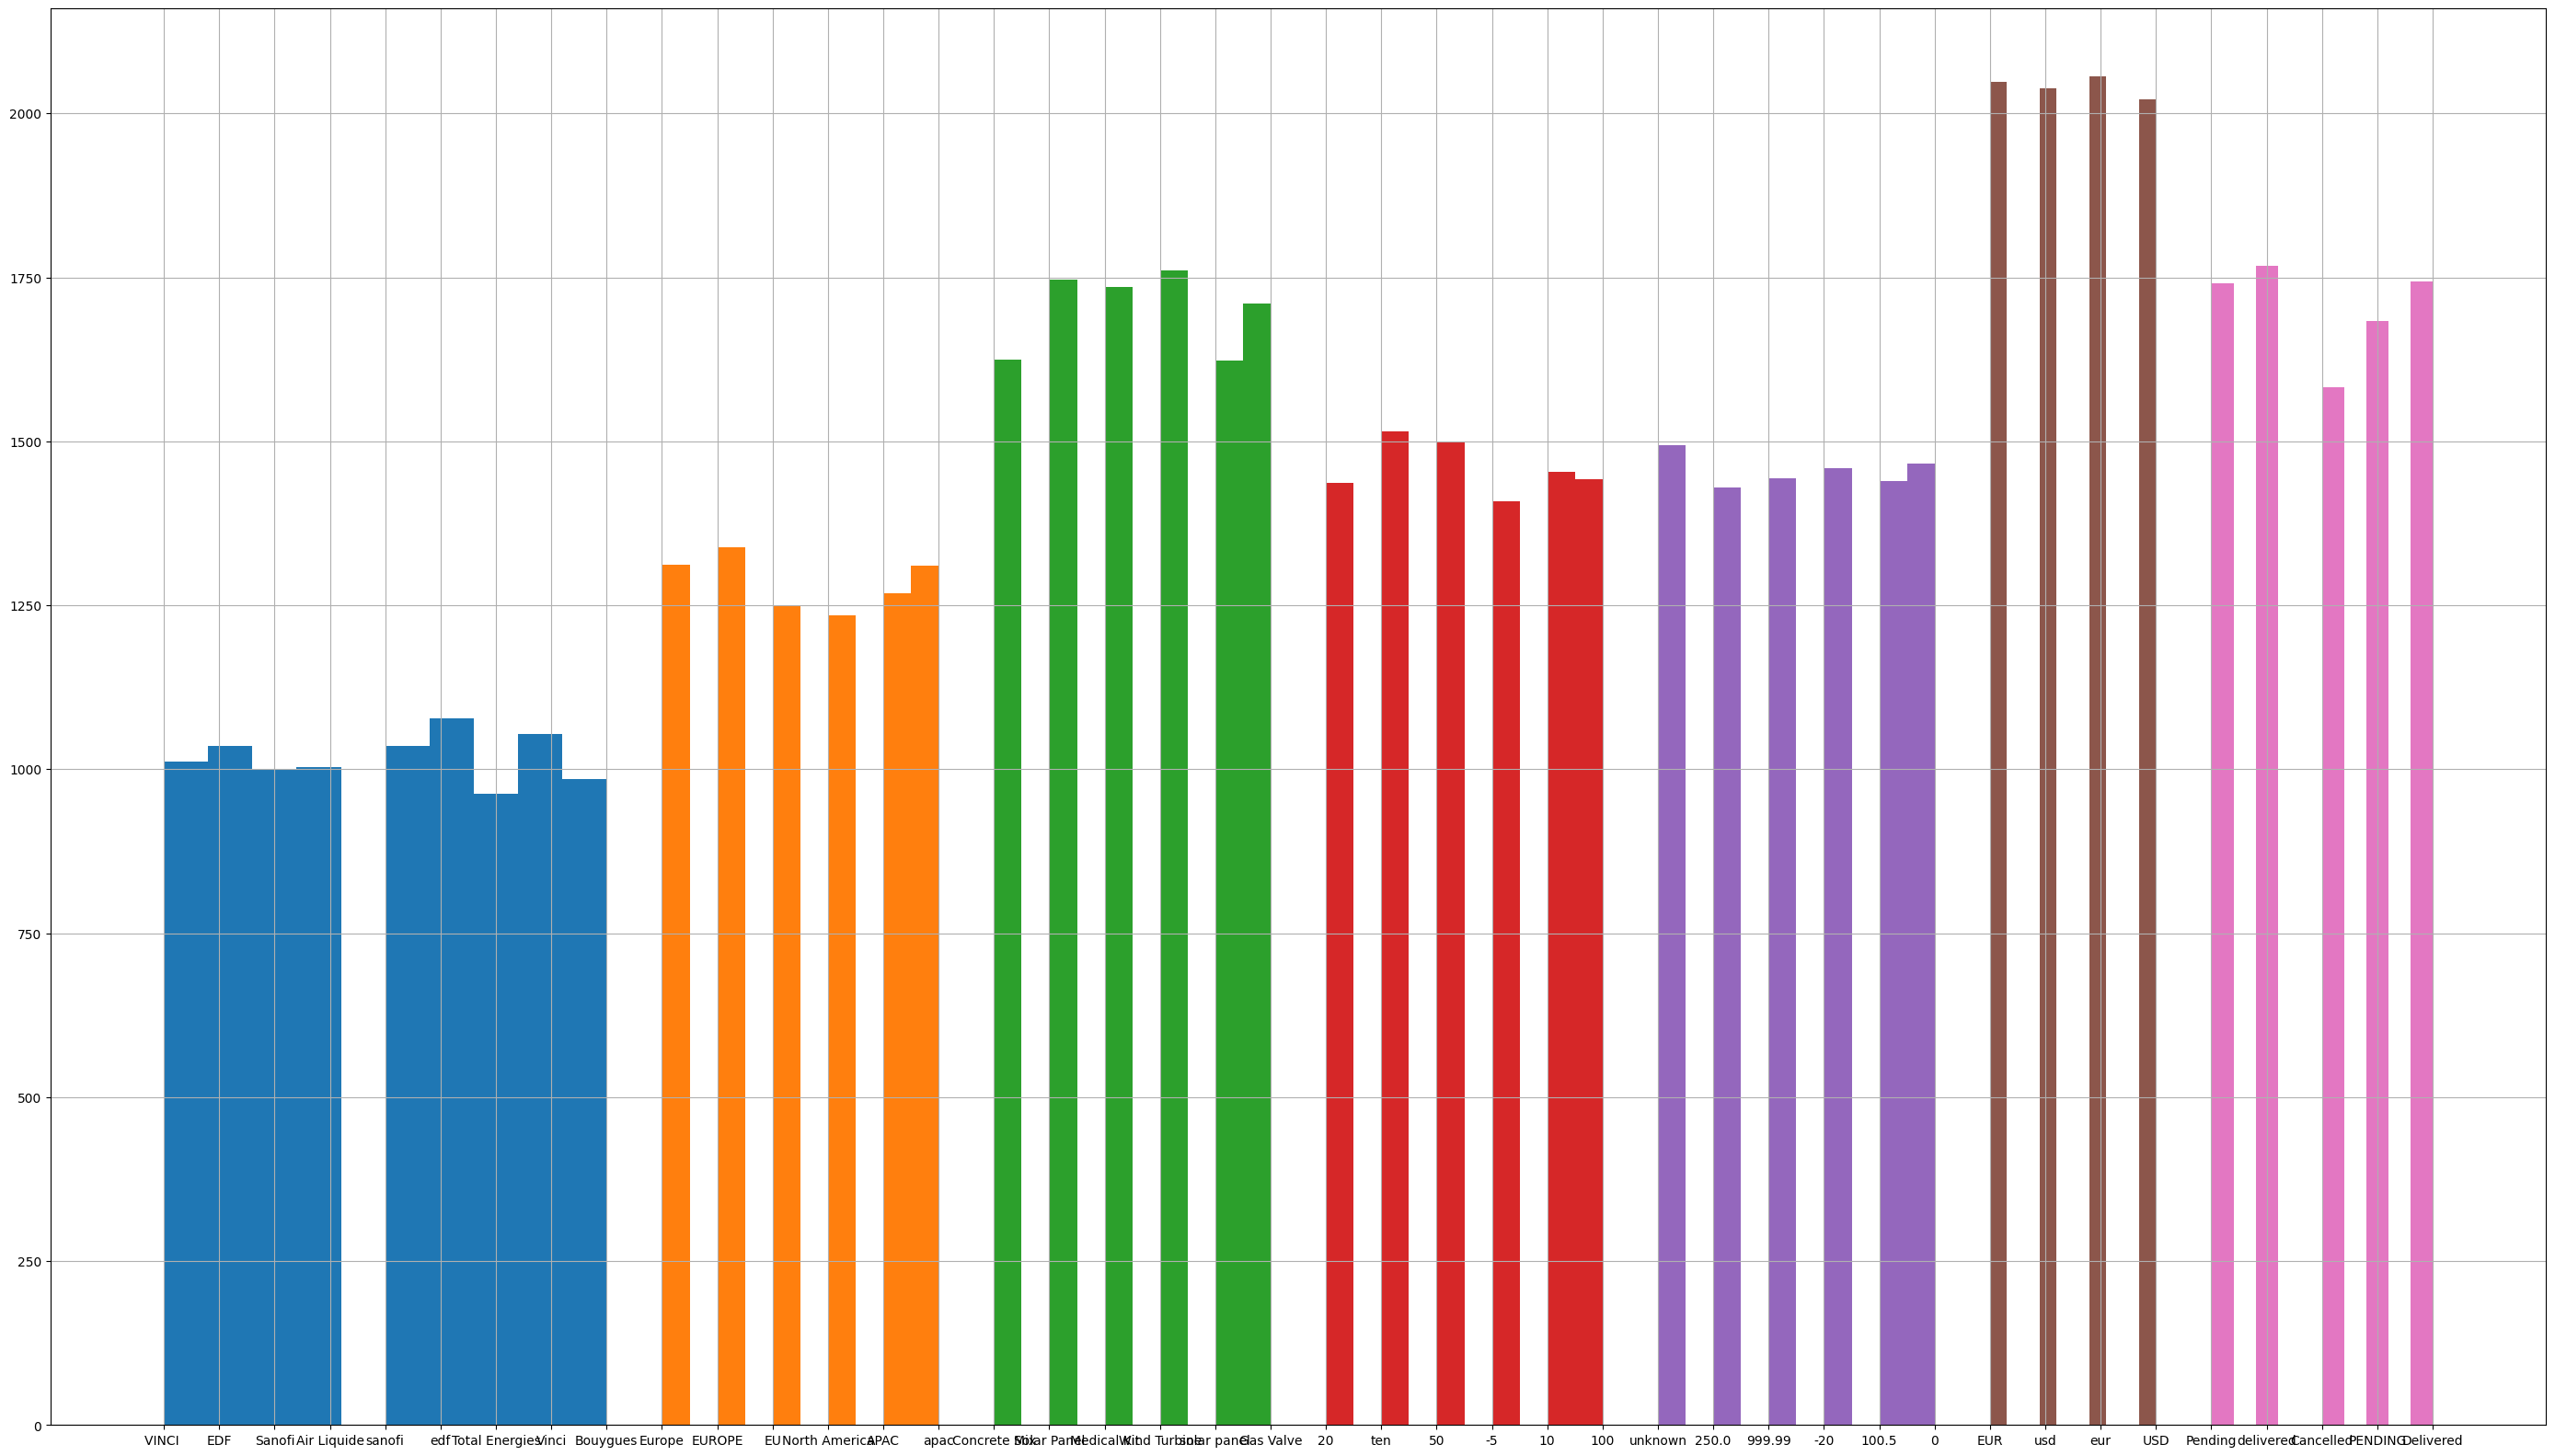

In [ ]:
# Distribution de valeurs dans chaque colonne
for col in columns_df:
    df[col].hist(figsize=(35,20))

In [ ]:
# Enregistrements duppliqués
dupplicated_records = df[df.duplicated()]
dupplicated_records

200

In [ ]:
len(dupplicated_records)

200

**EDA conclusion**
* La table comporte 9 colonnes et 10200 ligne dont 200 sont des lignes duppliqués
* Toutes les colonnes sont de type "object"
* Absence de valeur représente plus de 11% dans toute la table et varie entre 10% et 15% dans chaque colonne.
* Prsque toutes les colonnes présentent des inconsistences de données "MAUVAIS FORMATAGE"
  * customer_name : présence des espaces blancs pour le même attribut, mélange de majuscule et minuscule.
  * region : mélange de majuscule et minuscule pour le même attribut
  * product : mélange de majuscule et minuscule pour le même attribut
  * order_date : présence de plusieurs formats YYYY-MM-DD, DD/MM/YYYY...
  * quantity : chiffres et textes mélangés
  * currency : mélange de majuscule et minuscule pour le même attribut
  * status : mélange de majuscule et minuscule et majuscule au début pour le même attribut
* Valeurs aberrantes dans quelques colonnes
  * quantity : valeurs négatives
  * order_date : dates impossible comme 32 en JJ
  * unit_price : valeurs négatives, textes







---



**Data Cleaning**

--> Etapes :


1.   Suppression des enregistrements duppliquées
2.   Standardisation des données "Formatage"
3.   Gestion des valeurs aberrantes
4.   Gestion de l'abscence des valeurs "NaN"
5.   Post-Cleaning Validation





---



**1. Suppression des enregistrements duppliquées**

In [ ]:
df.drop_duplicates(inplace=True)

**2.   Standardisation des données "Formatage"**


  * customer_name :


      1.   Enlever les espaces blancs
      2.   Enlever les caractères non désirés comme caractères spéciaux et d'autres
      3.   Convertir en Majuscule



In [ ]:
# Création d'une fonction qui fait le nettoyage de base sur une colonne qui contient des chaîne de caractères : Important pour utilisation ultérieure
def clean_column_texte(df, col):
    df[col] = df[col].str.lower()                                  # minuscules
    df[col] = df[col].str.replace(r'[^a-z0-9\s]', ' ', regex=True) # tout sauf lettres/chiffres/espace → espace
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)         # réduire espaces multiples internes à 1
    df[col] = df[col].str.strip()                                   # enlever espaces début/fin
clean_column_texte(df, 'customer_name')

In [ ]:
# MAJUSCULE
df['customer_name'] = df['customer_name'].str.upper()
df['customer_name'].head(5)

,customer_name
0,VINCI
1,NaN
2,EDF
3,SANOFI
4,AIR LIQUIDE


* customer_name :


1.   Enlever les espaces blancs
2.   Enlever les caractères non désirés comme caractères spéciaux et d'autres
3.   Standardiser les variants de valeurs

In [ ]:
# Nettoyage de texte basique
clean_column_texte(df, 'region')
df['region'].unique()

array([nan, 'europe', 'eu', 'north america', 'apac'], dtype=object)

In [ ]:
# Dictionnaire de normalisation
region_map = {
    'europe': 'Europe',
    'eu': 'Europe',
    'north america': 'North America',
    'apac': 'APAC'
}
df['region'] = df['region'].replace(region_map)
df['region'].unique()

array([nan, 'Europe', 'North America', 'APAC'], dtype=object)

* product :


1.   Enlever les espaces blancs
2.   Enlever les caractères non désirés comme caractères spéciaux et d'autres
3.   Standardiser les variants de valeurs

In [ ]:
# Nettoyage de texte basique
clean_column_texte(df, 'product')
# Premier lettre de chaque mot --> MAJ
df['product'] = df['product'].str.title()
df['product'].unique()


array(['Concrete Mix', 'Solar Panel', 'Medical Kit', 'Wind Turbine',
       'Gas Valve'], dtype=object)

* order_date :


1.   Convertir en dtype : Datetime
2.   Standardiser les variants de valeurs : YYYY-MM-DD
3.   Se débarasser des dates impossible (indirectement) --> NaT

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

df[['order_date']].head(10)

,order_date
0,2023-01-06
1,2023-04-28
2,2023-07-21
3,2023-05-25
4,NaT
5,NaT
6,2023-05-15
7,2023-12-30
8,2024-01-05
9,2023-02-23


* quantity :


1.   Standardiser les variants de valeurs
2.   Convertir en chiffres

In [ ]:
# Remplaçage des chiffres écrits en format texte en chiffres
word_to_number = {
    'ten': 10
}

df['quantity'] = df['quantity'].replace(word_to_number)

In [ ]:
# Conversion le type de données en numérique
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

In [ ]:
df['quantity'].unique()

array([ 20.,  10.,  50.,  -5., 100.,  nan])

* unit_price :

1.   Convertir en chiffres
2.   Convertir en NaN ce qui n'est pas en chiffre

In [ ]:
# Conversion le type de données en numérique (Tout ce qui n'est pas chiffre passe en nan)
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')
df['unit_price'].unique()

array([   nan, 250.  , 999.99, -20.  , 100.5 ,   0.  ])

* currency :


1.   Enlever les espaces blancs
2.   Enlever les caractères non désirés comme caractères spéciaux et d'autres
3.   Standardiser les variants de valeurs

In [ ]:
# Nettoyage de texte basique
clean_column_texte(df, 'currency')
df['currency'].unique()

array([nan, 'eur', 'usd'], dtype=object)

In [ ]:
# MAJUSCULE
df['currency'] = df['currency'].str.upper()
df['currency'].unique()

array([nan, 'EUR', 'USD'], dtype=object)

* status :


1.   Enlever les espaces blancs
2.   Enlever les caractères non désirés comme caractères spéciaux et d'autres
3.   Standardiser les variants de valeurs

In [ ]:
# Nettoyage de texte basique
clean_column_texte(df, 'status')
df['status'].unique()

array([nan, 'pending', 'delivered', 'cancelled'], dtype=object)

In [ ]:
# Première lettre en MAJ
df['status'] = df['status'].str.title()
df['status'].unique()

array([nan, 'Pending', 'Delivered', 'Cancelled'], dtype=object)



*   conversion des types de donnés



In [ ]:
# Le type de données de plusieurs colonnes a été changé durant le processus du formatage
# On vérifie le type de données de chaque colonne
df.dtypes

,0
order_id,object
customer_name,object
region,object
product,object
order_date,datetime64[ns]
quantity,float64
unit_price,float64
currency,object
status,object


In [ ]:
# Les colonnes dont le type de données est "object" ne stocke que du texte, il est dont préférable de le changer en chaine de caractères "string"
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].astype('string')
# Vérification
df.dtypes

,0
order_id,string[python]
customer_name,string[python]
region,string[python]
product,string[python]
order_date,datetime64[ns]
quantity,float64
unit_price,float64
currency,string[python]
status,string[python]




---


**3.   Gestion des valeurs aberrantes**


À la base, trois colonnes contenaient des valeurs aberrantes :


*   order_date : dates impossibles; jour 32, mois 13...
*   quantity : valeurs négatives
*   unit_price : valeurs négatives, zéro



...



*   order_date

Les dates impossibles ont été converties indiectement lors du changement du dtype de la colonne "order_date" en NaT (Not a Date) pour une gestion ultérieure.



...



*   quantity

-5 est la seule valeur différente, la garder représente un risque car elle fausserait les totaux et les statistiques. Il est donc important de la remplacer par une valeur qui conserve l’information des commandes. La médiane des quantités positives est utilisée pour corriger l’anomalie tout en minimisant l’impact sur la distribution des données.

In [ ]:
# Compter le nombre de lignes avec quantity = -5
(df['quantity'] == -5 ).sum()

np.int64(1376)

In [ ]:
# Flag des anomalies pour une bonne traçabilité
df['quantity_flag_outlier'] = df['quantity'] == -5

In [ ]:
# Compter le nombre de lignes flagées (il doit correspondre aux nombre de lignes avec quantity = -5)
(df['quantity_flag_outlier'] == True).sum()

np.int64(1376)

In [ ]:
# Calcul de la médiane des valeurs positives de la colonne 'quantity'
median_quantity = df[df['quantity'] > 0]['quantity'].median()

# Remplacement des valeurs négatives par la médiane
df['quantity'] = df['quantity'].apply(lambda x: median_quantity if x == -5 else x)

# La valeur qui remplace -5
median_quantity

20.0



...


*   unit_price

Cette colonne  présente deux valeurs aberrantes (-20 et 0). Étant donné que le prix unitaire dépend uniquement du produit et la devise et que la colonne "product" ne contient aucune valeur manquante et la devise présente juste 2 valeurs un même produit ne devrait pas apparaître avec plus de 2 prix différents. Une analyse croisée produit–curreny-prix est donc à réaliser afin d’identifier les incohérences et remplacer les valeurs aberrantes par le prix de référence du produit. Si le teste ne passe pas un renseignement est obligatoire pour avoir les bon prix.

In [ ]:
# Pour chaque produit unit_prix et currency correspondants
df.groupby(["product", "currency"])["unit_price"].unique()

product       currency
Concrete Mix  EUR         [100.5, nan, 250.0, 0.0, 999.99, -20.0]
              USD         [nan, 250.0, 0.0, 999.99, -20.0, 100.5]
Gas Valve     EUR         [100.5, 250.0, -20.0, 999.99, nan, 0.0]
              USD         [-20.0, nan, 0.0, 100.5, 250.0, 999.99]
Medical Kit   EUR         [999.99, -20.0, 250.0, nan, 100.5, 0.0]
              USD         [100.5, nan, 250.0, 999.99, 0.0, -20.0]
Solar Panel   EUR         [100.5, 250.0, 0.0, 999.99, nan, -20.0]
              USD         [0.0, 250.0, nan, -20.0, 100.5, 999.99]
Wind Turbine  EUR         [100.5, 999.99, 0.0, -20.0, 250.0, nan]
              USD         [-20.0, 250.0, 100.5, 0.0, nan, 999.99]
Name: unit_price, dtype: object

Dans l'étape précédente on voit bien que tous les prix qui existent dans la base sont présent avec tous les produit --> Incohérence

Donc maintenanat un renseignement sur le prix est primordial pour maintenir en cohérence solide (prix en fonction du "product" et "currence")

In [ ]:
# Dictionnaire : Référence de prix
price_reference = {
    ('Concrete Mix', 'EUR'): 100.5,
    ('Concrete Mix', 'USD'): 110,
    ('Solar Panel', 'EUR'): 250,
    ('Solar Panel', 'USD'): 270,
    ('Medical Kit', 'EUR'): 50,
    ('Medical Kit', 'USD'): 55,
    ('Wind Turbine', 'EUR'): 999.99,
    ('Wind Turbine', 'USD'): 1050,
    ('Gas Valve', 'EUR'): 20,
    ('Gas Valve', 'USD'): 22,
}
# Remplacer avec les bons prix
df['unit_price'] = list(
    zip(df['product'], df['currency'])
)

df['unit_price'] = df['unit_price'].map(price_reference)
#Vérification
df.groupby(["product", "currency"])["unit_price"].unique()

product       currency
Concrete Mix  EUR          [100.5]
              USD          [110.0]
Gas Valve     EUR           [20.0]
              USD           [22.0]
Medical Kit   EUR           [50.0]
              USD           [55.0]
Solar Panel   EUR          [250.0]
              USD          [270.0]
Wind Turbine  EUR         [999.99]
              USD         [1050.0]
Name: unit_price, dtype: object



---


**4. Gestion de l'abscence des valeurs "NaN"**

Les valeurs des NaN a changé indirectement lors des étapes précédentes et cela pour plusieurs raisons :


*   Plusieurs lignes dupliquées ont été supprimées.
*   Le formatage de plusieurs colonnes a modifié le nombre de valeurs NaN : certaines ont disparu tandis que de nouvelles ont été créées.
*   Quelques valeurs aberrantes ont été remplacées par des NaN.

In [ ]:
# Vérification

column_nullvalues = df.isna().sum()
column_nullvalues_rate = df.isna().mean() * 100
column_nullvalues_summary = pd.concat(
    [column_nullvalues, column_nullvalues_rate],
    axis=1
)

column_nullvalues_summary

,0,1
order_id,0,0.00
customer_name,1014,10.14
region,2430,24.30
product,0,0.00
order_date,1012,10.12
quantity,1416,14.16
unit_price,1994,19.94
currency,1994,19.94
status,1652,16.52
quantity_flag_outlier,0,0.00


...

customer_name, region, status : Les colonnes catégorielles (customer_name, region, status) ont été imputées par la valeur "Unknown".

In [ ]:
df["customer_name"] = df["customer_name"].fillna("Unknown")
df["region"] = df["region"].fillna("Unknown")
df["status"] = df["status"].fillna("Unknown")

...

'currency' : Vu que la devise ne dépénd ni de la region ni du client, il serait logique et stable de remplacer les NaN de la colonne 'currency' par la valeur majoritairement présente.

In [ ]:
# La devise n'est pas en fonction de la région et le client
df.groupby(["region", "customer_name"])["currency"].unique()

region         customer_name 
APAC           AIR LIQUIDE       [EUR, <NA>, USD]
               BOUYGUES          [EUR, <NA>, USD]
               EDF               [USD, EUR, <NA>]
               SANOFI            [EUR, USD, <NA>]
               TOTAL ENERGIES    [EUR, USD, <NA>]
               Unknown           [USD, EUR, <NA>]
               VINCI             [USD, EUR, <NA>]
Europe         AIR LIQUIDE       [EUR, USD, <NA>]
               BOUYGUES          [USD, EUR, <NA>]
               EDF               [<NA>, USD, EUR]
               SANOFI            [EUR, USD, <NA>]
               TOTAL ENERGIES    [<NA>, EUR, USD]
               Unknown           [<NA>, USD, EUR]
               VINCI             [<NA>, USD, EUR]
North America  AIR LIQUIDE       [USD, EUR, <NA>]
               BOUYGUES          [USD, EUR, <NA>]
               EDF               [EUR, <NA>, USD]
               SANOFI            [<NA>, USD, EUR]
               TOTAL ENERGIES    [EUR, USD, <NA>]
               Unknown           [USD, <NA>, EUR]
               VINCI             [USD, EUR, <NA>]
Unknown        AIR LIQUIDE       [USD, <NA>, EUR]
               BOUYGUES          [USD, EUR, <NA>]
               EDF               [EUR, USD, <NA>]
               SANOFI            [EUR, <NA>, USD]
               TOTAL ENERGIES    [EUR, USD, <NA>]
               Unknown           [EUR, <NA>, USD]
               VINCI             [<NA>, EUR, USD]
Name: currency, dtype: object

In [ ]:
# Compter combien de fois chaque devise est présente
df.groupby("currency")["currency"].count()

,currency
currency,
EUR,4027
USD,3979


In [ ]:
# #Flag des cellules qui contenait NaN
df["currency_flag_nan"] = df["currency"].isna()
# On remplace par la valeur prépondérante
df["currency"] = df["currency"].fillna(df["currency"].mode()[0])

In [ ]:
# Vérification (on doit avoir 4027 + NaN(currency)=1994 = 6021)
df.groupby("currency")["currency"].count()

,currency
currency,
EUR,6021
USD,3979


...

'order_date' : La date de le commande est très importante pour l'analyse, le fait qu'il soit absente rend la ligne mois utile donc il est important de la supprimer

In [ ]:
df = df.dropna(subset=["order_date"])

...

'quantity' : On remplace par la médiane pour minimiser l'impact sur la distribution des données.

In [ ]:
# Flag des cellules qui contenait NaN
df["quantity_flag_nan"] = df["quantity"].isna()
# On remplace par la médiane
df["quantity"] = df["quantity"].fillna(df["quantity"].median())

...

'unit_price' : On applique directement la référence du prix qu'on a utilisé avant pour corriger la colonne 'unit_price' (avant elle a pas été appliqué sur toutes les lignes car la colonne 'currency' contenait NaN maintenanat)

In [ ]:
df['unit_price'] = list(
    zip(df['product'], df['currency'])
)

df['unit_price'] = df['unit_price'].map(price_reference)

---

**5.   Post-Cleaning Validation**

In [ ]:
# Taux de réduction
rows_after = df.shape[0]
# 10200 correspond au nombre de lignes avant nettoyage
reduction_rate = (10200-rows_after)*100/10200
f"Reduction: {reduction_rate:.2f}%"

'Reduction: 11.88%'

In [ ]:
# Vérification du type des données
df.dtypes

,0
order_id,string[python]
customer_name,string[python]
region,string[python]
product,string[python]
order_date,datetime64[ns]
quantity,float64
unit_price,float64
currency,string[python]
status,string[python]
quantity_flag_outlier,bool


In [ ]:
# Enregistrements duppliqués
dupplicated_records = df[df.duplicated()]
len(dupplicated_records)

0

In [ ]:
# Nombre de NaN dans la table
df.isna().sum().sum()

np.int64(0)

In [ ]:
# Nombre de NaN dans chaque colonne
df.isna().sum()

,0
order_id,0
customer_name,0
region,0
product,0
order_date,0
quantity,0
unit_price,0
currency,0
status,0
quantity_flag_outlier,0


In [ ]:
# Standardisation du formatage
for c in columns_df:
    print(f"{c}:", df[c].unique()) # Aucune anomalie liée au formatage des colonnes n’a été identifiée.

customer_name: <StringArray>
[         'VINCI',        'Unknown',            'EDF',         'SANOFI',
    'AIR LIQUIDE', 'TOTAL ENERGIES',       'BOUYGUES']
Length: 7, dtype: string
region: <StringArray>
['Unknown', 'Europe', 'North America', 'APAC']
Length: 4, dtype: string
product: <StringArray>
['Concrete Mix', 'Solar Panel', 'Medical Kit', 'Gas Valve', 'Wind Turbine']
Length: 5, dtype: string
quantity: [ 20.  10.  50. 100.]
unit_price: [ 100.5   250.     50.    270.     20.    999.99   22.   1050.    110.
   55.  ]
currency: <StringArray>
['EUR', 'USD']
Length: 2, dtype: string
status: <StringArray>
['Unknown', 'Pending', 'Delivered', 'Cancelled']
Length: 4, dtype: string


In [ ]:
# Valeurs aberrantes dans les colonnes numériques
df[['quantity','unit_price']].describe() # Tout semble cohérent

,quantity,unit_price
count,8988.000000,8988.000000
mean,32.763685,288.218615
std,29.983397,343.938525
min,10.000000,20.000000
25%,10.000000,50.000000
50%,20.000000,250.000000
75%,50.000000,270.000000
max,100.000000,1050.000000


array([[<Axes: title={'center': 'quantity'}>,
        <Axes: title={'center': 'unit_price'}>]], dtype=object)

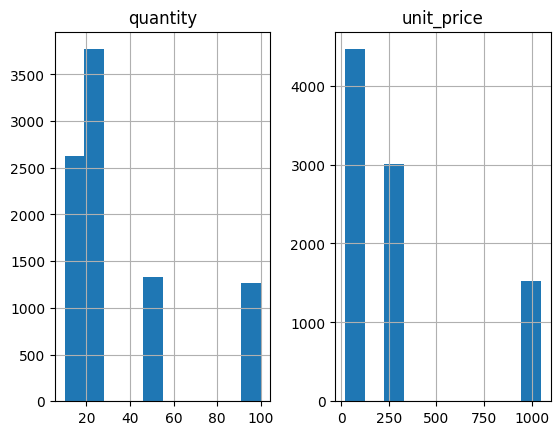

In [ ]:
# Distribution des données dans les valeurs numériques
df[['quantity','unit_price']].hist() # Pas de divergences identifiées

In [ ]:
# Apperçu de la table nettoyée
df.head(50)

,order_id,customer_name,region,product,order_date,quantity,unit_price,currency,status,quantity_flag_outlier,currency_flag_nan,quantity_flag_nan
0,ORD108575,VINCI,Unknown,Concrete Mix,2023-01-06,20.0,100.50,EUR,Unknown,False,True,False
1,ORD103742,Unknown,Europe,Solar Panel,2023-04-28,10.0,250.00,EUR,Pending,False,True,False
2,ORD106231,EDF,Europe,Medical Kit,2023-07-21,10.0,50.00,EUR,Delivered,False,True,False
3,ORD105723,SANOFI,Europe,Medical Kit,2023-05-25,50.0,50.00,EUR,Cancelled,False,False,False
6,ORD103149,SANOFI,Europe,Solar Panel,2023-05-15,10.0,270.00,USD,Delivered,False,False,False
7,ORD102876,SANOFI,Europe,Gas Valve,2023-12-30,100.0,20.00,EUR,Delivered,False,False,False
8,ORD105914,VINCI,North America,Solar Panel,2024-01-05,10.0,270.00,USD,Delivered,False,False,False
9,ORD107744,EDF,Unknown,Medical Kit,2023-02-23,100.0,50.00,EUR,Pending,False,False,False
10,ORD105700,AIR LIQUIDE,Europe,Medical Kit,2023-03-07,10.0,50.00,EUR,Unknown,False,False,False
11,ORD104689,TOTAL ENERGIES,Europe,Gas Valve,2024-05-15,100.0,20.00,EUR,Pending,False,True,False


In [ ]:
# Exportation de la data
export_path = "/content/drive/MyDrive/DataAnalysis/DataCleaning/CleanedSalesB2BDataset.xlsx"
df.to_excel(export_path, index=False)